In [1]:
import numpy as np
from matplotlib import pyplot as plt
import scipy
from dcalib import read_dca1000

path_to_folder="/Volumes/Elements/mmWaveData/"

In [2]:
path_to_folder="/Users/manavjeet/Library/CloudStorage/GoogleDrive-manavjeet.singh@stonybrook.edu/My Drive/mmWave/12_16_1Tx4Rx"
# path_to_folder="./"

In [3]:
fileName="/Users/manavjeet/git/mmWave-Heartbeat-Dataset-Preprocessing-Toolbox-/1023dataset/gby1023data/adc_1023gby1_Raw_0.bin"
# fileName=f"{path_to_folder}12_8_1Tx4Rx/highres_nomovement_normalbreathing_60cm_2.bin"
# fileName=f"{path_to_folder}12_16_1Tx4Rx/manavjeet_nomovement_nobreathing2.bin"
# fileName=f"{path_to_folder}/aditya_tshirt_nomovement_nobreathing3.bin"
# fileName=f"{path_to_folder}/aditya_nomovement_nobreathing1.bin"
# fileName=f"{path_to_folder}/samir_nomovement_nobreathing5.bin"
# fileName=f"{path_to_folder}12_16_1Tx4Rx/aditya_tshirt_nomovement_nobreathing1.bin"


In [4]:
num_samples=400
num_rx=4
dca_out=read_dca1000(fileName,num_adc_samples = num_samples, num_adc_bits = 16, num_rx=num_rx)

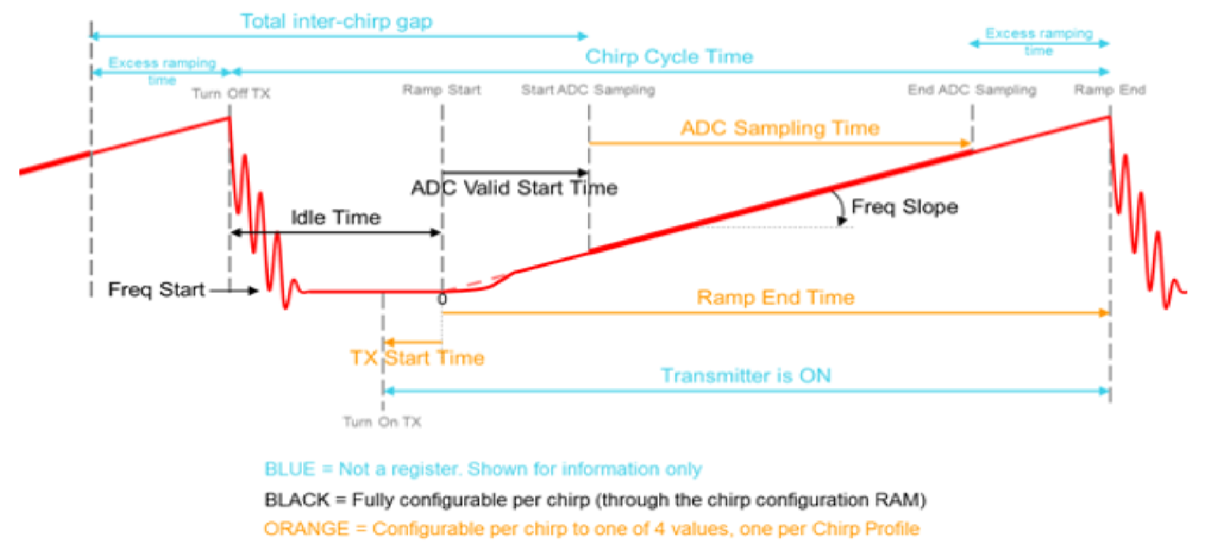

In [5]:
# sampling_frequency = 12000 * 1e3 # Hz (example)
sampling_frequency = 4000 * 1e3 # Hz (example)
S=77.006e12 #mhz/us
start_freq=60*1e9
ramp_end=60 #us
idle_time=100 #us
periodicity=40 #us
chirp_cycle_time=(idle_time + ramp_end + periodicity) * 1e-6
pulse_repetation_interval = 1/chirp_cycle_time
num_rx=1
num_chirps=1
samples_per_chirp=num_samples
range_max=3e8*sampling_frequency/ (2*S)

frames_per_loop=2
chirp_loops=1024

dca_out.shape[1]/samples_per_chirp/chirp_loops/frames_per_loop

1.0

In [6]:
dca_out.shape

(4, 819200)

In [7]:
def minmax_normalize(arr):
    min_val = np.min(arr)
    max_val = np.max(arr)
    
    if max_val - min_val == 0:
        return np.zeros_like(arr)
        
    arr_std = (arr - min_val) / (max_val - min_val)
    
    return arr_std

def make_data_cube(dca_data, num_rx):
    global samples_per_chirp, chirp_loops, frames_per_loop
    num_chirps=chirp_loops*frames_per_loop
    adc_data_shape = (num_chirps, num_rx, samples_per_chirp)
    adc_data = np.zeros(adc_data_shape, dtype=np.complex128)
    for chnl in range(num_rx):
        for chrp in range(num_chirps):
            adc_data[chrp, chnl, :] = dca_data[chnl][chrp*samples_per_chirp:(chrp+1)*samples_per_chirp]
            
    return adc_data
    

In [8]:
print("Dca out shape:", dca_out.shape)  # (num_frames, num_rx, num_samples)
print("Few data samples:", dca_out[0][:5])
adc_data=make_data_cube(dca_out, num_rx=dca_out.shape[0])
print("Data cube shape:", adc_data.shape)

Dca out shape: (4, 819200)
Few data samples: [ -500.+1565.j -1360.+1834.j  -700. +498.j -1052. +508.j   674. +831.j]
Data cube shape: (2048, 4, 400)


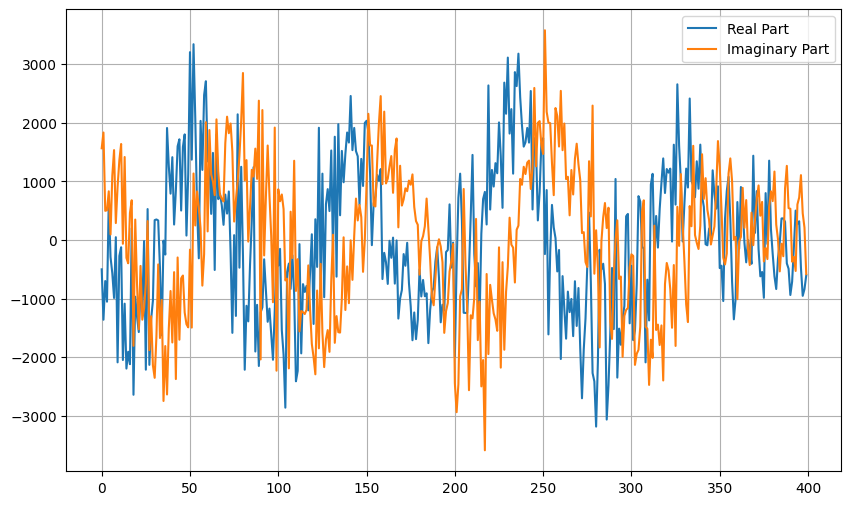

In [9]:
# Time domain
plt.figure(figsize=(10, 6))
chirp=0
channe=0
data = adc_data[chirp, channe, :]
real=data.real
complex_data=data.imag
plt.plot(real,'-',label='Real Part')
plt.plot(complex_data,'-',label='Imaginary Part')
plt.grid()
plt.legend()

### Range FFT

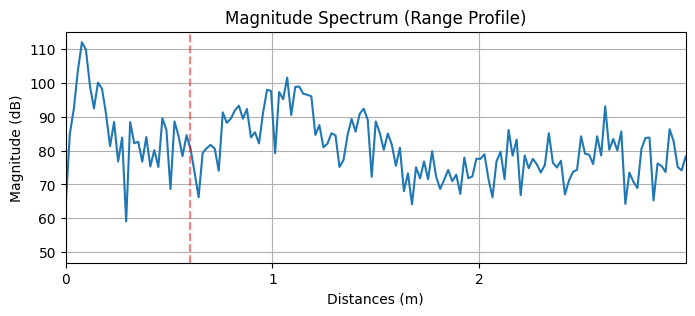

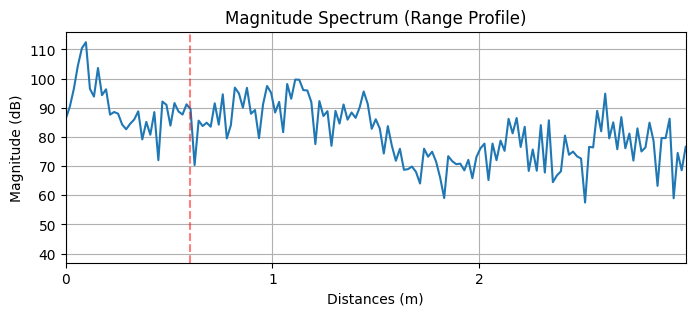

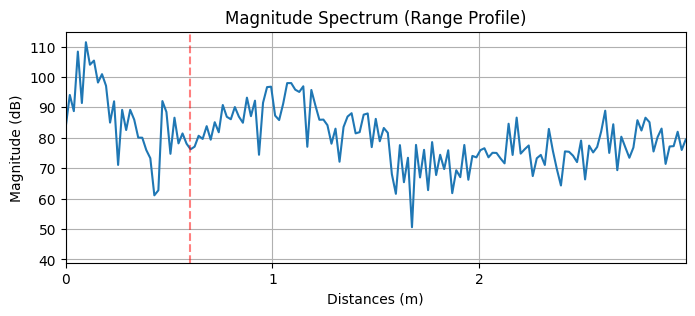

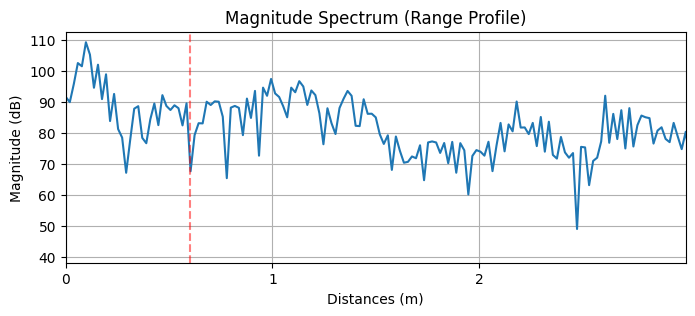

In [10]:
distance_idx=14
def magnitude_dbfs(fft_data, adc_bits=16):
        """
        Convert complex FFT to magnitude in dBFS (decibels relative to full scale)
        
        Args:
            fft_data: Complex FFT output array
            adc_bits: ADC resolution in bits (default 12-bit for typical radar)
        
        Returns:
            magnitude_dbfs: Magnitude in dBFS scale
        """
        # Calculate full scale value based on ADC bits
        full_scale = 2**(adc_bits - 1)  # For signed ADC
        
        # Get magnitude of FFT
        magnitude = np.abs(fft_data)
        
        # Normalize by FFT length (important for proper scaling)
        magnitude_normalized = magnitude / len(fft_data)
        
        # Convert to dBFS: 20*log10(magnitude / full_scale)
        # Add small epsilon to avoid log(0)
        magnitude_dbfs = 20 * np.log10(magnitude_normalized / full_scale + 1e-10)
        
        return magnitude_dbfs

def magnitude_db(fft_data):
        """Convert complex FFT to magnitude in dB"""
        magnitude = np.abs(fft_data)
        magnitude_db = 20 * np.log10(magnitude + 1e-10)  # Add small value to avoid log(0)
        return magnitude_db

def rangeFFT(signal, plot=False):
    global range_max
    num_samples = len(signal)
    window = np.hanning(num_samples)
    signal_windowed = signal
    y=np.fft.fft(signal_windowed)
    # print(len(signal_windowed), len(y))
    fft_magnitude = magnitude_db(y,)
    # fft_magnitude = magnitude_dbfs(y,adc_bits=16)

    # frequencies = np.fft.fftshift(np.fft.fftfreq(num_samples, d=1/(sampling_frequency)))
    # distances=np.abs(frequencies)*3e8/2/S
    distances=np.arange(num_samples) * range_max / num_samples
    # print([distances[0],distances[-100]])
    if plot:
        # Plot the magnitude spectrum
        plt.figure(figsize=[8,3])
        # plt.plot(frequencies[:num_samples//2], fft_magnitude[:num_samples//2]) # Plot only positive frequencies
        # plt.plot(distances[:num_samples//2], fft_magnitude[:num_samples//2]) # Plot only positive frequencies
        plt.plot(distances, fft_magnitude) # Plot only positive frequencies
        plt.title('Magnitude Spectrum (Range Profile)')
        # plt.xlabel('Frequency (Hz) / Range Bins')
        plt.xlabel('Distances (m)')
        plt.ylabel('Magnitude (dB)')
        plt.xticks(np.arange(0,range_max//2,1))
        plt.xlim([0,range_max//2])
        plt.grid(True)
        plt.axvline(x=0.6, color='r', linestyle='--', alpha=0.5)
        plt.show()
    return y, fft_magnitude, distances

rangeFFTAcrossChirps=np.zeros(adc_data.shape,dtype=np.complex128) 
for chnl in range(adc_data.shape[1]):
    for chirp_no in range(adc_data.shape[0]):
        if chirp_no==0:
            fft_signal, fft_magnitude, distances=rangeFFT(adc_data[chirp_no, chnl,:], plot=True)
        else:
            fft_signal, fft_magnitude, distances=rangeFFT(adc_data[chirp_no, chnl,:], plot=False)
        rangeFFTAcrossChirps[chirp_no,chnl,:]=fft_signal

In [ ]:
rangeFFTAcrossChirps.shape

(2048, 4, 400)

<Figure size 1000x500 with 0 Axes>

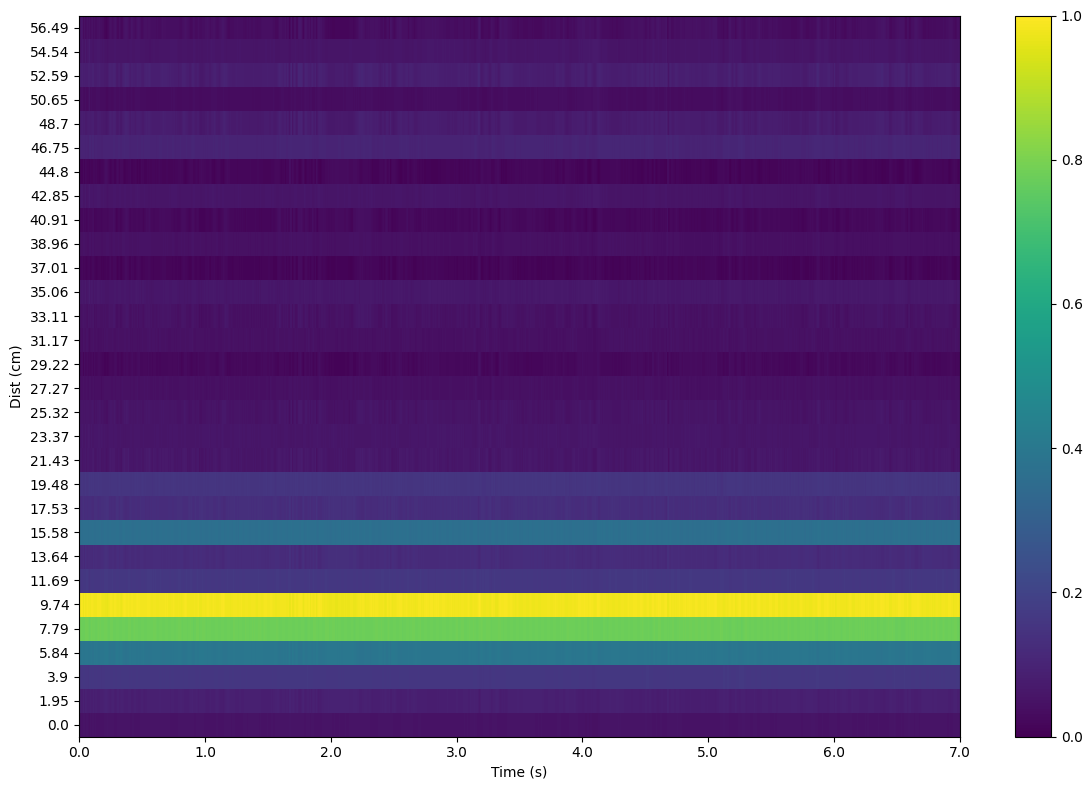

In [ ]:
# Example 2D array (replace with your own)
def plot_spectogram(rangeFFTAcrossChirps,distances, rx_channel=None):
    distances=np.array(distances)
    plt.figure(figsize=(12, 8))
    idxes=np.arange(0,30)
    x_idxes=np.arange(0,rangeFFTAcrossChirps.shape[0])
    rangeFFTAcrossChirps_abs=np.abs(rangeFFTAcrossChirps)
    
    #Whole spectogram min max normalization.
    if rx_channel!=None:
        rangeFFTAcrossChirps_norm=minmax_normalize(rangeFFTAcrossChirps_abs[:,rx_channel,idxes])
    else:
        rangeFFTAcrossChirps_norm=minmax_normalize(rangeFFTAcrossChirps_abs[:,idxes])
        
    
    # #Individual range bin minmax normalizations.
    # rangeFFTAcrossChirps_norm=np.zeros([rangeFFTAcrossChirps.shape[0], len(idxes)],dtype=np.float32)
    # for row_idx,row in enumerate(idxes):
    #     if rx_channel!=None:
    #         rangeFFTAcrossChirps_norm[:,row_idx] = minmax_normalize(rangeFFTAcrossChirps_abs[:, rx_channel, row])
    #     else:
    #         rangeFFTAcrossChirps_norm[:,row_idx] = minmax_normalize(rangeFFTAcrossChirps_abs[:, row])
            
    
    
    
    plt.imshow((rangeFFTAcrossChirps_norm.T), aspect='auto', cmap='viridis', origin='lower',  interpolation='nearest')
    # plt.imshow(magnitude_db(rangeFFTAcrossChirps[idxes,:]), aspect='auto', cmap='viridis', origin='lower')

    yticks = np.arange(len(rangeFFTAcrossChirps[idxes]))        # positions 0..19
    ytick_labels = np.round(distances[idxes]*100,2)                  # your labels
    plt.yticks(yticks, ytick_labels)



    # --- Create x-ticks for 0–7 seconds ---
    total_time = 7  # seconds
    num_ticks = 8   # ticks at 0,1,2,...,7 sec

    tick_positions = np.linspace(0, rangeFFTAcrossChirps.shape[0]-1, num_ticks)
    tick_labels = np.linspace(0, total_time, num_ticks)
    plt.xticks(tick_positions, tick_labels)
    plt.xlabel("Time (s)")
    plt.ylabel("Dist (cm)")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


plot_spectogram(rangeFFTAcrossChirps,distances, rx_channel=1)

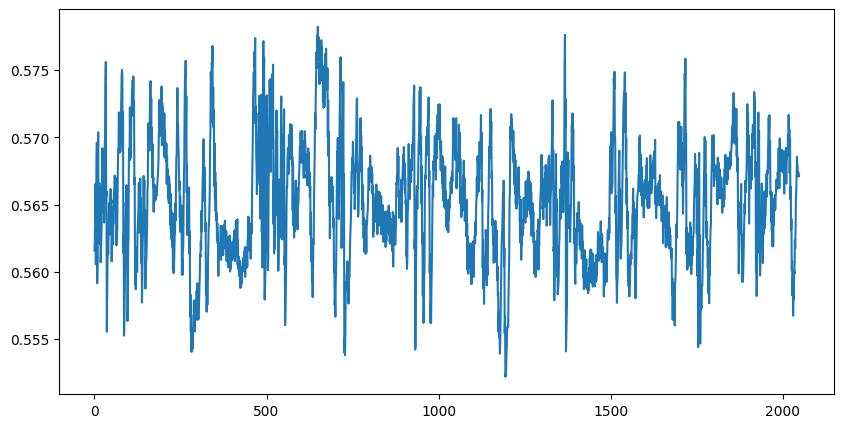

In [26]:
plt.figure(figsize=(10,5))
plt.plot(np.arange(2048),np.angle(rangeFFTAcrossChirps[:, 1, 5]))

In [13]:
num_rx=rangeFFTAcrossChirps.shape[1]

num_angle_bins = 64
all_chirp_beamformed_data=np.zeros([rangeFFTAcrossChirps.shape[0], num_angle_bins, rangeFFTAcrossChirps.shape[2]])

for chirp_no in range(rangeFFTAcrossChirps.shape[0]):
    # Shape: (chirps, rx, range_bins)
    # Let's process the first chirp for a Range-Angle Map
    data_slice = rangeFFTAcrossChirps[chirp_no, :, :] 

    # 1. Apply windowing across the RX dimension (axis 0 here)
    window = np.hamming(num_rx).reshape(num_rx, 1)
    windowed_data = data_slice * window

    # 2. Zero-pad for better angular resolution (e.g., to 64 points)
    # FFT across the RX dimension (axis 0)
    beamformed_data = np.fft.fft(windowed_data, n=num_angle_bins, axis=0)

    # 3. Shift the zero-frequency component to the center
    beamformed_data = np.fft.fftshift(beamformed_data, axes=0)

    # 4. Convert to Magnitude (Power)
    range_angle_map = np.abs(beamformed_data)
    all_chirp_beamformed_data[chirp_no,:,:]=range_angle_map
    # break



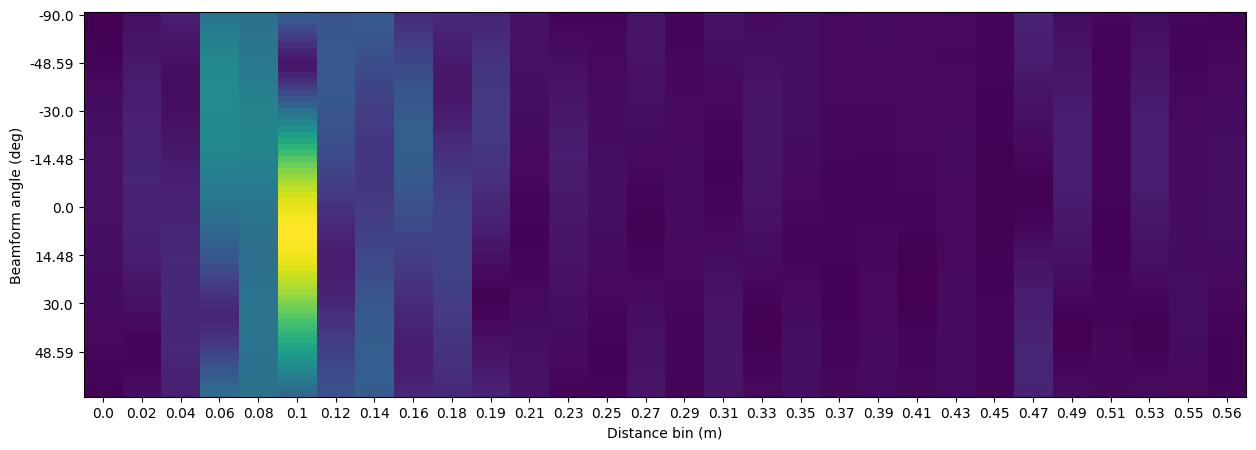

In [14]:
_lambda=3e8/79e9

# 1. Create centered bin indices: [-N/2, ..., N/2 - 1]
# This corresponds to what np.fft.fftshift does to your data
bin_indices = np.arange(-num_angle_bins//2, num_angle_bins//2)

# 2. Calculate the term inside the arcsin
# Note: we use (d * num_angle_bins) as the denominator
rescale_factor = (bin_indices * _lambda) / (_lambda/2 * num_angle_bins)

# 3. Clip the values to avoid float precision errors (like 1.00000000001)
rescale_factor = np.clip(rescale_factor, -1.0, 1.0)

# 4. Convert to angles (radians)
angles_deg = np.rad2deg(np.arcsin(rescale_factor))

idxes=np.arange(0,30)
y_idxes = np.arange(0,num_angle_bins,8)
plt.figure(figsize=[15,5])
plt.imshow(all_chirp_beamformed_data[100,:,idxes].T, interpolation='none', aspect='auto',)
# plt.xticks(distances[:30])
plt.xticks(idxes, np.round(distances[idxes],2))
plt.yticks(y_idxes, np.round(angles_deg[y_idxes],2))
plt.xlabel("Distance bin (m)")
plt.ylabel("Beamform angle (deg)")
plt.show()

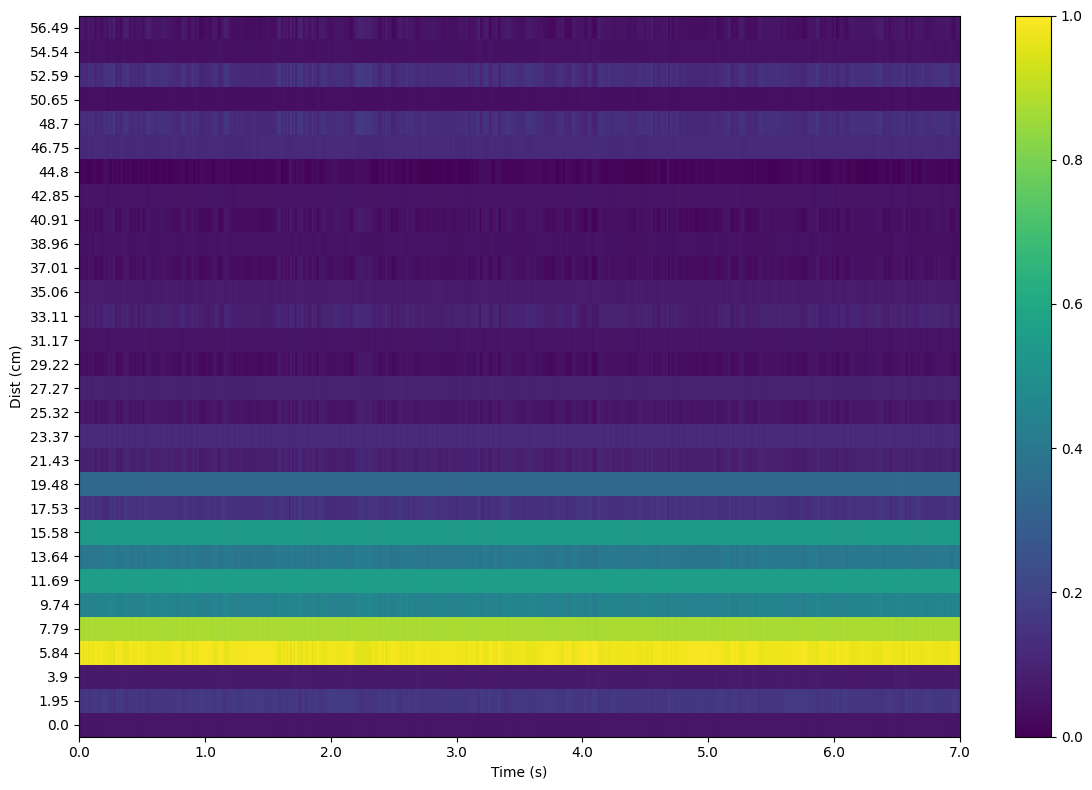

In [18]:
all_chirp_beamformed_data[:,32,:].shape
plot_spectogram(all_chirp_beamformed_data[:,13,:],distances)

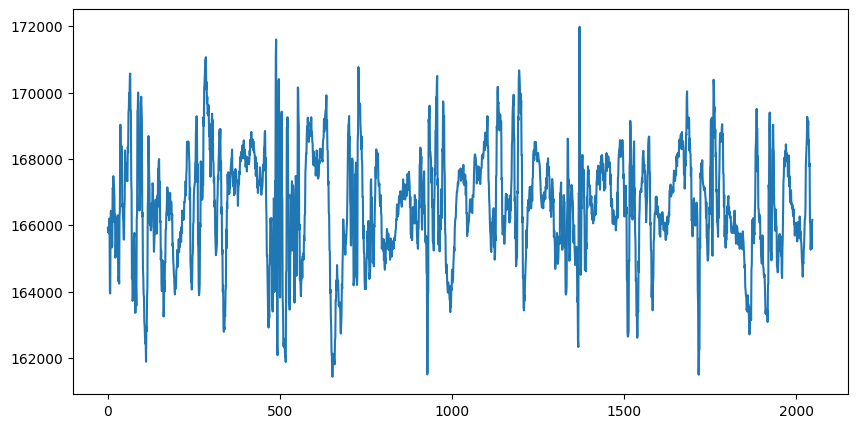

In [30]:
plt.figure(figsize=(10,5))
plt.plot((np.abs(rangeFFTAcrossChirps[:,1,3])))